<a href="https://colab.research.google.com/github/royhridoy965-sketch/AI-and-ML-Lab/blob/main/CNN/CNN_RPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import os
import shutil

# Clone the repository
repo_url = 'https://github.com/rakinbd/CNN.git'
repo_dir = 'CNN_rakin'
if os.path.exists(repo_dir):
    shutil.rmtree(repo_dir)

print(f'Cloning repository {repo_url}...')
!git clone {repo_url} {repo_dir}

# Fix structure: Move files into class subfolders
dataset_path = os.path.join(repo_dir, 'Dataset')
classes = ['Rock', 'Paper', 'Scissor']

for cls in classes:
    os.makedirs(os.path.join(dataset_path, cls), exist_ok=True)

for filename in os.listdir(dataset_path):
    file_path = os.path.join(dataset_path, filename)
    if os.path.isfile(file_path):
        for cls in classes:
            if cls in filename:
                shutil.move(file_path, os.path.join(dataset_path, cls, filename))
                break

print(f'Organized classes: {os.listdir(dataset_path)}')

Cloning repository https://github.com/rakinbd/CNN.git...
Cloning into 'CNN_rakin'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (13/13), done.
Receiving objects: 100% (17/17), 1.34 MiB | 6.25 MiB/s, done.
remote: Total 17 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Organized classes: ['Paper', 'Scissor', '.gitkeep', 'Rock']


In [14]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch

# Define transforms
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset from the new path
# Note: This assumes the 'Dataset' folder contains subfolders for each class
full_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

# Split into Train and Validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Classes found: {full_dataset.classes}")
print(f"Total images: {len(full_dataset)}")

Classes found: ['Paper', 'Rock', 'Scissor']
Total images: 10


In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import os

# Configuration
dataset_path = 'CNN_rakin/Dataset'

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Verify folders exist after modification
full_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
num_classes = len(full_dataset.classes)

class NewCNN(nn.Module):
    def __init__(self, num_classes):
        super(NewCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 32 * 32)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = NewCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size])
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False)

print(f'Model ready for classes: {full_dataset.classes}')

Model ready for classes: ['Paper', 'Rock', 'Scissor']


In [16]:
# Training block with variable validation
try:
    train_loader
    model
except NameError:
    # Re-initialize loaders if state was lost
    from torchvision import datasets, transforms
    from torch.utils.data import DataLoader, random_split
    dataset_path = 'CNN_new/Dataset'
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    full_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss/len(train_loader):.4f}, Val Acc: {100 * correct / total:.2f}%')

Epoch [1/5], Loss: 3.7207, Val Acc: 0.00%
Epoch [2/5], Loss: 2.0221, Val Acc: 50.00%
Epoch [3/5], Loss: 1.4179, Val Acc: 50.00%
Epoch [4/5], Loss: 0.4381, Val Acc: 0.00%
Epoch [5/5], Loss: 0.3018, Val Acc: 100.00%


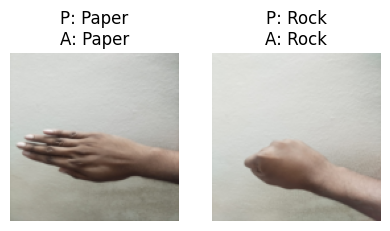

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Visualization block
model.eval()
dataiter = iter(val_loader)
images, labels = next(dataiter)

outputs = model(images.to(device))
_, predicted = torch.max(outputs, 1)

plt.figure(figsize=(10, 4))
for i in range(min(4, len(images))):
    plt.subplot(1, 4, i+1)
    img = images[i]
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    plt.imshow(img.permute(1, 2, 0).clamp(0, 1))
    plt.title(f'P: {full_dataset.classes[predicted[i]]}\nA: {full_dataset.classes[labels[i]]}')
    plt.axis('off')
plt.show()

Epoch 1/10 - Loss: 0.0638
Epoch 2/10 - Loss: 0.0115
Epoch 3/10 - Loss: 0.0013
Epoch 4/10 - Loss: 0.0002
Epoch 5/10 - Loss: 0.0002
Epoch 6/10 - Loss: 0.0001
Epoch 7/10 - Loss: 0.0000
Epoch 8/10 - Loss: 0.0000
Epoch 9/10 - Loss: 0.0000
Epoch 10/10 - Loss: 0.0000


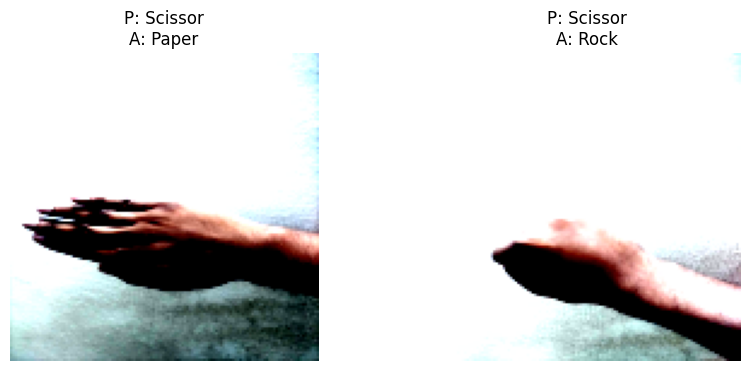

In [18]:
# Training and Visualization
num_epochs = 10
model.train()
for epoch in range(num_epochs):
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f'Epoch {epoch+1}/{num_epochs} - Loss: {total_loss/len(train_loader):.4f}')

# Visualize prediction
model.eval()
images, labels = next(iter(val_loader))
with torch.no_grad():
    outputs = model(images.to(device))
    _, preds = torch.max(outputs, 1)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
for i in range(len(images)):
    plt.subplot(1, len(images), i+1)
    plt.imshow(images[i].permute(1, 2, 0).cpu().numpy().clip(0, 1))
    plt.title(f'P: {full_dataset.classes[preds[i]]}\nA: {full_dataset.classes[labels[i]]}')
    plt.axis('off')
plt.show()

In [42]:
!git clone https://github.com/rakinbd/CNN.git

Cloning into 'CNN'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 17 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), 1.34 MiB | 335.00 KiB/s, done.


In [43]:
import os

print(os.listdir("CNN/Dataset"))

['Paper_2.jpeg', 'Paper_3.jpeg', '.gitkeep', 'Scissor_3.jpeg', 'Paper_4.jpeg', 'Rock_1.jpeg', 'Scissor_2.jpeg', 'Scissor_1.jpeg', 'Rock_3.jpeg', 'Paper_1.jpeg', 'Rock_2.jpeg']


In [44]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
GPU available: True


In [45]:
import os
import zipfile
import urllib.request

# Create data folder
os.makedirs("rps_data", exist_ok=True)

# Download training dataset
train_url = "https://storage.googleapis.com/download.tensorflow.org/data/rps.zip"
train_zip = "rps_train.zip"

urllib.request.urlretrieve(train_url, train_zip)

# Extract training dataset
with zipfile.ZipFile(train_zip, "r") as zip_ref:
    zip_ref.extractall("rps_data")

print("RPS training dataset downloaded and extracted successfully!")

RPS training dataset downloaded and extracted successfully!


In [46]:
import os

base_path = "rps_data/rps"

for class_name in ["rock", "paper", "scissors"]:
    class_path = os.path.join(base_path, class_name)
    images = os.listdir(class_path)
    print(f"{class_name}: {len(images)} images")

rock: 840 images
paper: 840 images
scissors: 840 images


In [47]:
from torch.utils.data import DataLoader, random_split

# Split dataset into 70% training, 15% validation, 15% test
total_size = len(dataset)

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Total images:", total_size)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("DataLoaders created successfully!")

Total images: 2520
Training images: 1764
Validation images: 378
Test images: 378
DataLoaders created successfully!


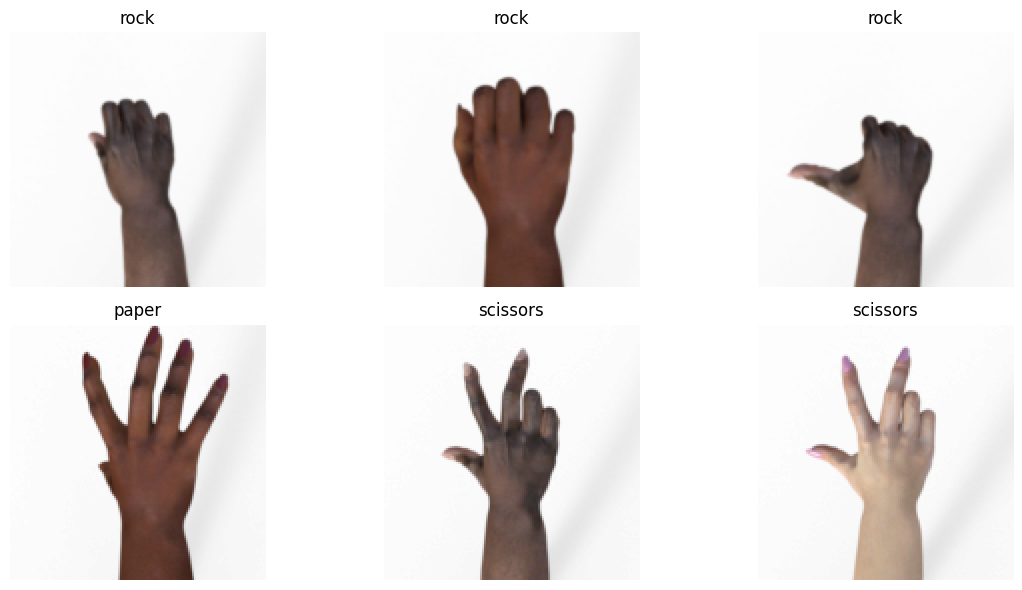

In [48]:
import matplotlib.pyplot as plt

# Get one batch
images, labels = next(iter(train_loader))

# Display 6 images
plt.figure(figsize=(12, 6))

for i in range(6):
    plt.subplot(2, 3, i + 1)

    # Convert tensor to displayable image
    img = images[i].permute(1, 2, 0)

    # Undo normalization for visualization
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])

    img = img * std + mean
    img = torch.clamp(img, 0, 1)

    plt.imshow(img)
    plt.title(dataset.classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [49]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            # Convolution 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Convolution 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Convolution 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Create model
model = CNN()

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


In [50]:
# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to device
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Device:", device)
print("Loss Function:", criterion)
print("Optimizer: Adam")

Device: cuda
Loss Function: CrossEntropyLoss()
Optimizer: Adam


In [51]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


In [53]:
import os

print(os.listdir("CNN/Dataset"))

['Paper_2.jpeg', 'Paper_3.jpeg', '.gitkeep', 'Scissor_3.jpeg', 'Paper_4.jpeg', 'Rock_1.jpeg', 'Scissor_2.jpeg', 'Scissor_1.jpeg', 'Rock_3.jpeg', 'Paper_1.jpeg', 'Rock_2.jpeg']


In [54]:
import os
import zipfile
import urllib.request

# Create data folder
os.makedirs("rps_data", exist_ok=True)

# Download standard RPS dataset
train_url = "https://storage.googleapis.com/download.tensorflow.org/data/rps.zip"
train_zip = "rps_train.zip"

urllib.request.urlretrieve(train_url, train_zip)

# Extract dataset
with zipfile.ZipFile(train_zip, "r") as zip_ref:
    zip_ref.extractall("rps_data")

print("RPS training dataset downloaded and extracted successfully!")

RPS training dataset downloaded and extracted successfully!


In [55]:
import os

base_path = "rps_data/rps"

for class_name in ["rock", "paper", "scissors"]:
    class_path = os.path.join(base_path, class_name)
    images = os.listdir(class_path)
    print(f"{class_name}: {len(images)} images")

rock: 840 images
paper: 840 images
scissors: 840 images


In [56]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load RPS dataset
dataset = datasets.ImageFolder(
    root="rps_data/rps",
    transform=transform
)

# Split: 80% training, 20% validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Classes: ['paper', 'rock', 'scissors']
Total images: 2520
Training images: 2016
Validation images: 504


In [57]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            # Convolution 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Convolution 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Convolution 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Create model
model = CNN()

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


In [58]:
# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to GPU
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Loss Function:", criterion)
print("Optimizer: Adam")

Device: cuda
GPU: Tesla T4
Loss Function: CrossEntropyLoss()
Optimizer: Adam


In [59]:
# Number of epochs
num_epochs = 10

# Store training history
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    # =========================
    # Training
    # =========================
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    # =========================
    # Validation
    # =========================
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    # Save history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/10] | Train Loss: 0.9636 | Train Acc: 61.31% | Val Loss: 0.3079 | Val Acc: 89.48%
Epoch [2/10] | Train Loss: 0.0918 | Train Acc: 97.87% | Val Loss: 0.0561 | Val Acc: 97.02%
Epoch [3/10] | Train Loss: 0.0272 | Train Acc: 99.26% | Val Loss: 0.0054 | Val Acc: 99.80%
Epoch [4/10] | Train Loss: 0.0023 | Train Acc: 100.00% | Val Loss: 0.0017 | Val Acc: 100.00%
Epoch [5/10] | Train Loss: 0.0007 | Train Acc: 100.00% | Val Loss: 0.0010 | Val Acc: 100.00%
Epoch [6/10] | Train Loss: 0.0003 | Train Acc: 100.00% | Val Loss: 0.0008 | Val Acc: 100.00%
Epoch [7/10] | Train Loss: 0.0002 | Train Acc: 100.00% | Val Loss: 0.0005 | Val Acc: 100.00%
Epoch [8/10] | Train Loss: 0.0002 | Train Acc: 100.00% | Val Loss: 0.0004 | Val Acc: 100.00%
Epoch [9/10] | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0006 | Val Acc: 100.00%
Epoch [10/10] | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0003 | Val Acc: 100.00%


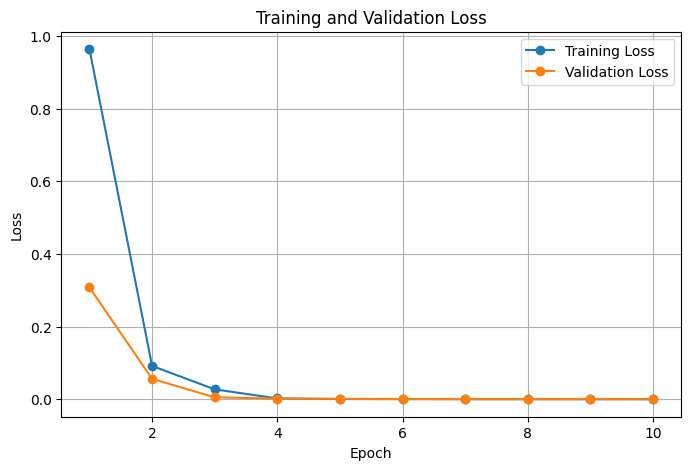

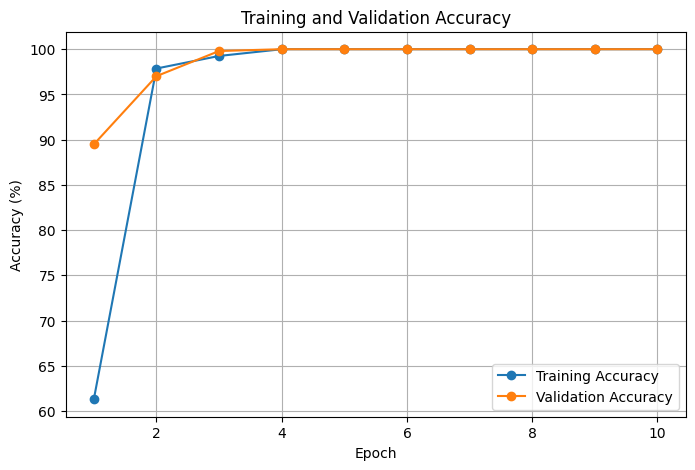

In [60]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

# =========================
# Loss Graph
# =========================
plt.figure(figsize=(8, 5))

plt.plot(epochs, train_losses, marker='o', label='Training Loss')
plt.plot(epochs, val_losses, marker='o', label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.show()


# =========================
# Accuracy Graph
# =========================
plt.figure(figsize=(8, 5))

plt.plot(epochs, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(epochs, val_accuracies, marker='o', label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [61]:
# Save trained model state dictionary
import os

model_path = "AI-and-ML-Lab/CNN/model/CNN_RPS.pth"
os.makedirs(os.path.dirname(model_path), exist_ok=True)

torch.save(model.state_dict(), model_path)

print("Model saved successfully!")
print("Saved at:", model_path)

Model saved successfully!
Saved at: AI-and-ML-Lab/CNN/model/CNN_RPS.pth


In [62]:
import os

model_path = "AI-and-ML-Lab/CNN/model/CNN_RPS.pth"

if os.path.exists(model_path):
    print("Model file found!")
    print("File size:", os.path.getsize(model_path) / (1024 * 1024), "MB")
else:
    print("Model file not found!")

Model file found!
File size: 16.361454963684082 MB


Test Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

       paper       1.00      1.00      1.00       115
        rock       1.00      1.00      1.00       135
    scissors       1.00      1.00      1.00       128

    accuracy                           1.00       378
   macro avg       1.00      1.00      1.00       378
weighted avg       1.00      1.00      1.00       378



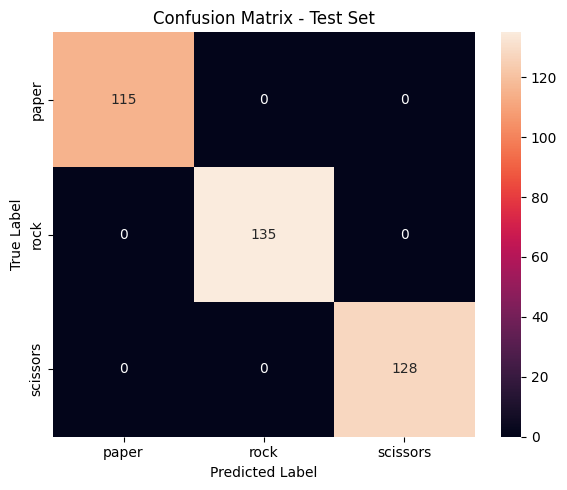

In [63]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Evaluation mode
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Accuracy
test_accuracy = accuracy_score(all_labels, all_predictions)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=dataset.classes
    )
)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

In [64]:
# Save the newly trained model
model_path = "AI-and-ML-Lab/CNN/model/CNN_RPS.pth"

torch.save(model.state_dict(), model_path)

print("New trained model saved successfully!")
print("Saved at:", model_path)

New trained model saved successfully!
Saved at: AI-and-ML-Lab/CNN/model/CNN_RPS.pth


In [65]:
from google.colab import files

files.download("AI-and-ML-Lab/CNN/model/CNN_RPS.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Put model in evaluation mode
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())


# Calculate evaluation metrics
accuracy = accuracy_score(all_labels, all_predictions)

precision = precision_score(
    all_labels,
    all_predictions,
    average='weighted',
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    average='weighted',
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average='weighted',
    zero_division=0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


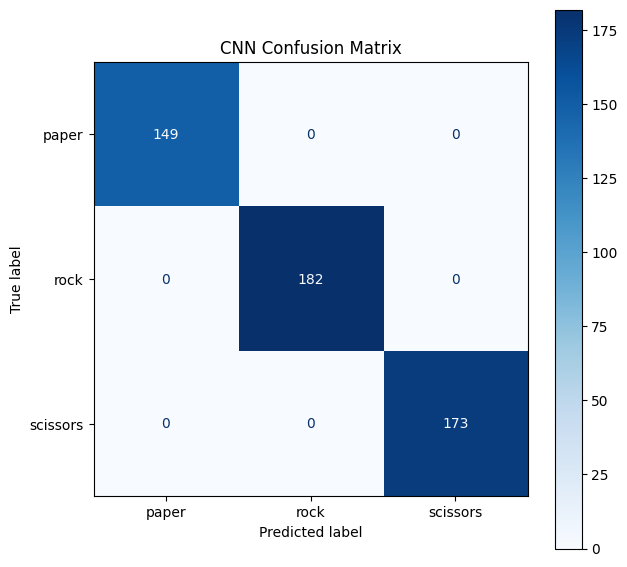

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dataset.classes
)

fig, ax = plt.subplots(figsize=(7, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("CNN Confusion Matrix")
plt.show()

In [68]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_predictions,
    target_names=dataset.classes,
    digits=4
)

print(report)

              precision    recall  f1-score   support

       paper     1.0000    1.0000    1.0000       149
        rock     1.0000    1.0000    1.0000       182
    scissors     1.0000    1.0000    1.0000       173

    accuracy                         1.0000       504
   macro avg     1.0000    1.0000    1.0000       504
weighted avg     1.0000    1.0000    1.0000       504



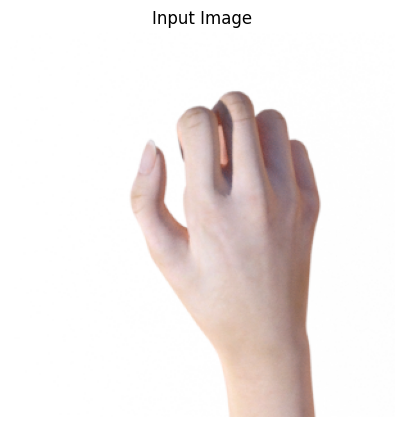

Actual class: rock
Predicted class: rock


In [69]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Take one image from the dataset
image_path = "rps_data/rps/rock/rock01-000.png"

# Open image
image = Image.open(image_path).convert("RGB")

# Show image
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

# Apply preprocessing
input_image = transform(image).unsqueeze(0).to(device)

# Prediction
model.eval()

with torch.no_grad():
    output = model(input_image)
    _, predicted = torch.max(output, 1)

predicted_class = dataset.classes[predicted.item()]

print("Actual class: rock")
print("Predicted class:", predicted_class)

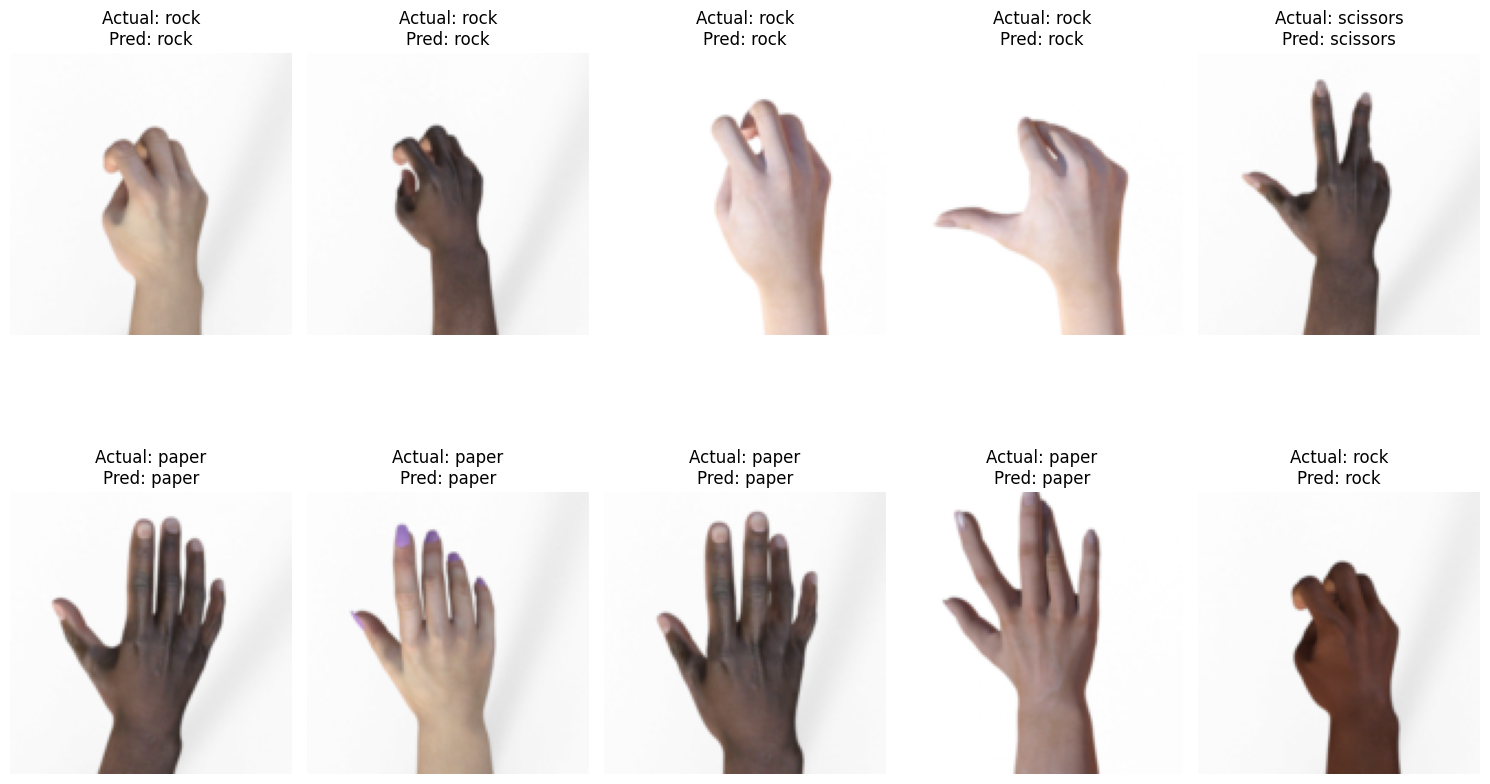

Correct predictions: 10/10
Sample accuracy: 100.00%


In [70]:
import random
import matplotlib.pyplot as plt

# Select 10 random validation images
samples = random.sample(range(len(val_dataset)), 10)

plt.figure(figsize=(15, 10))

correct_count = 0

for i, idx in enumerate(samples):

    image_tensor, label = val_dataset[idx]

    # Add batch dimension and move to device
    input_image = image_tensor.unsqueeze(0).to(device)

    # Prediction
    model.eval()

    with torch.no_grad():
        output = model(input_image)
        _, predicted = torch.max(output, 1)

    actual_class = dataset.classes[label]
    predicted_class = dataset.classes[predicted.item()]

    if actual_class == predicted_class:
        correct_count += 1

    # Display image
    image_display = image_tensor.cpu()

    # Undo normalization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    image_display = image_display * std + mean
    image_display = torch.clamp(image_display, 0, 1)

    image_display = image_display.permute(1, 2, 0)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image_display)
    plt.title(
        f"Actual: {actual_class}\nPred: {predicted_class}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

print(f"Correct predictions: {correct_count}/10")
print(f"Sample accuracy: {correct_count/10*100:.2f}%")

Total images found: 10


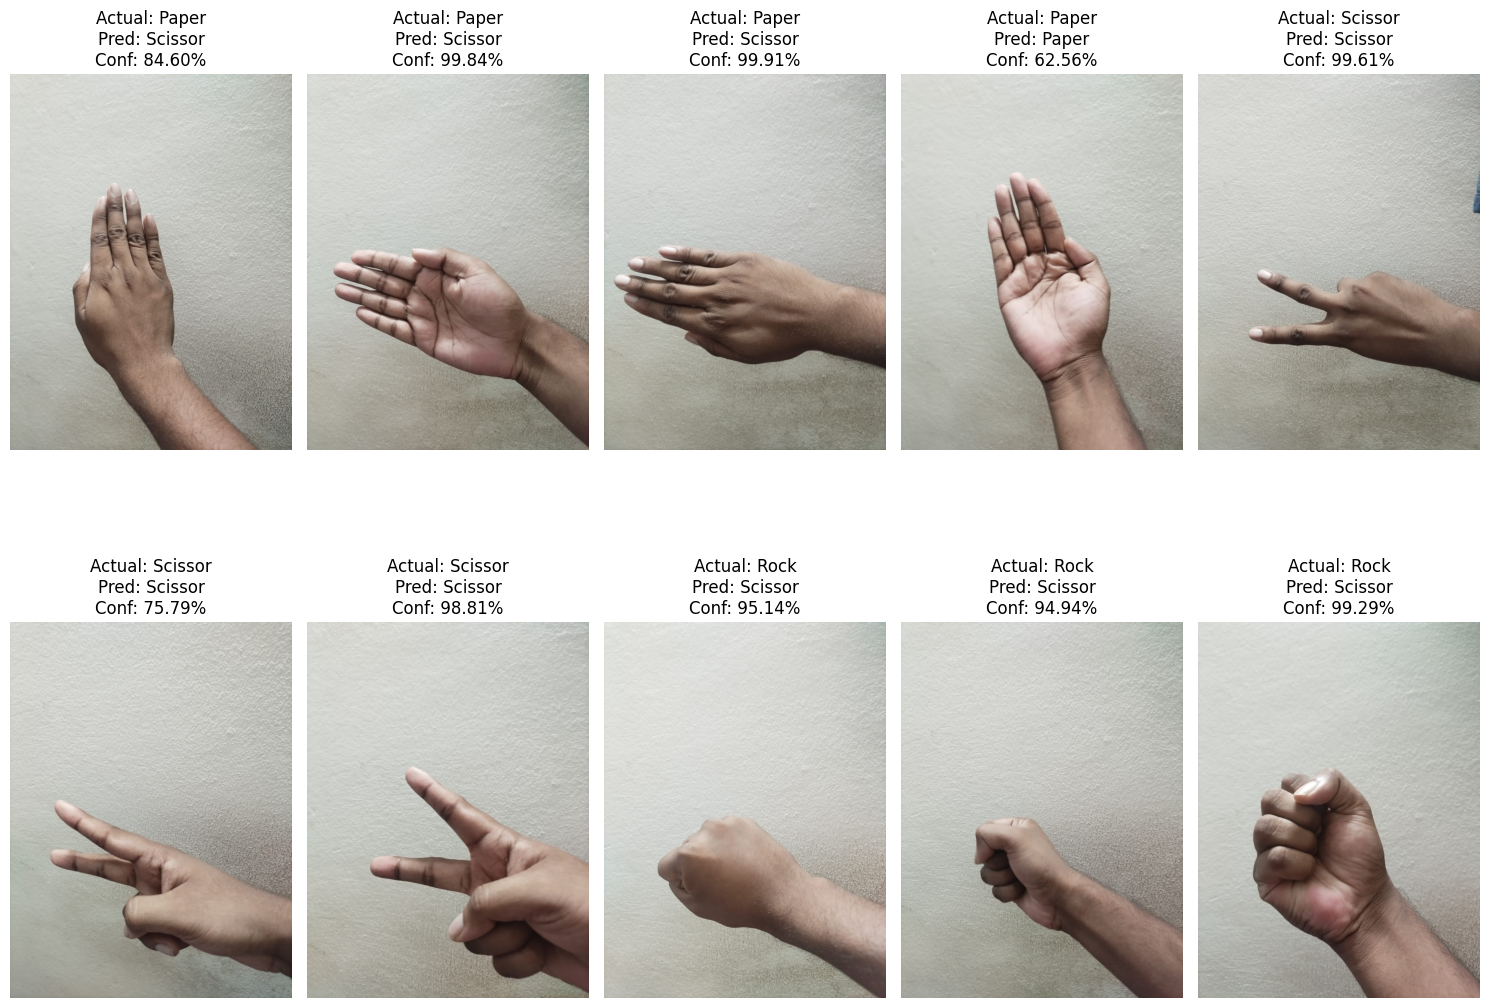

Correct predictions (first 10): 4/10
Subset accuracy: 40.00%


In [73]:
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt
import torch

# Updated path to the organized dataset from the requested repo
custom_path = "CNN_rakin/Dataset"

# Get all image files from subdirectories
image_paths = []
for root, dirs, files in os.walk(custom_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(root, file))

print("Total images found:", len(image_paths))

if len(image_paths) > 0:
    # Prediction
    model.eval()
    correct_count = 0
    plt.figure(figsize=(15, 12))

    # Only display up to 10 images to avoid clutter
    display_limit = min(10, len(image_paths))

    for i in range(display_limit):
        image_path = image_paths[i]
        image = Image.open(image_path).convert("RGB")

        # Preprocessing
        input_image = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_image)
            probabilities = torch.softmax(output, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        # Mapping prediction to the correct class list from full_dataset
        predicted_class = full_dataset.classes[predicted.item()]
        confidence_value = confidence.item() * 100

        # Infer actual class from the parent directory name
        actual_class = os.path.basename(os.path.dirname(image_path))

        if actual_class.lower() == predicted_class.lower():
            correct_count += 1

        plt.subplot(2, 5, i + 1)
        plt.imshow(image)
        plt.title(f"Actual: {actual_class}\nPred: {predicted_class}\nConf: {confidence_value:.2f}%")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Correct predictions (first {display_limit}): {correct_count}/{display_limit}")
    print(f"Subset accuracy: {(correct_count / display_limit) * 100:.2f}%")
else:
    print("No images found in the specified directory. Please check if the dataset was correctly organized in cell dca1e265.")

In [75]:
import shutil
import os

# Define the source and destination paths based on the notebook state
source = "CNN_rakin/Dataset/Rock/Rock_1.jpeg"
destination_dir = "AI-and-ML-Lab/CNN/dataset/"
os.makedirs(destination_dir, exist_ok=True)

destination = os.path.join(destination_dir, "rock_01.jpeg")

if os.path.exists(source):
    shutil.copy(source, destination)
    print(f"Successfully copied {source} to {destination}")
else:
    print(f"Error: Source file {source} not found. Please ensure the dataset was cloned and organized.")

Successfully copied CNN_rakin/Dataset/Rock/Rock_1.jpeg to AI-and-ML-Lab/CNN/dataset/rock_01.jpeg


In [76]:
import random
import matplotlib.pyplot as plt

# Put model in evaluation mode
model.eval()

# Store misclassified images
misclassified = []

with torch.no_grad():

    for idx in range(len(val_dataset)):

        image_tensor, true_label = val_dataset[idx]

        # Add batch dimension
        input_image = image_tensor.unsqueeze(0).to(device)

        # Prediction
        output = model(input_image)
        _, predicted = torch.max(output, 1)

        predicted_label = predicted.item()

        # Store only incorrect predictions
        if predicted_label != true_label:
            misclassified.append(
                (image_tensor, true_label, predicted_label)
            )

# Randomly select up to 3 incorrect images
num_errors = min(3, len(misclassified))

selected_errors = random.sample(
    misclassified,
    num_errors
)

# Display incorrect predictions
plt.figure(figsize=(12, 4))

for i, (image_tensor, true_label, predicted_label) in enumerate(selected_errors):

    # Undo normalization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    image_display = image_tensor.cpu() * std + mean
    image_display = torch.clamp(image_display, 0, 1)

    image_display = image_display.permute(1, 2, 0)

    plt.subplot(1, num_errors, i + 1)
    plt.imshow(image_display)

    plt.title(
        f"True: {dataset.classes[true_label]}\n"
        f"Predicted: {dataset.classes[predicted_label]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

print("Total misclassified images:", len(misclassified))
print("Displayed error examples:", num_errors)

<Figure size 1200x400 with 0 Axes>

Total misclassified images: 0
Displayed error examples: 0
